Saving VO2 data (phase tansition lab) - Sheet1 (10).csv to VO2 data (phase tansition lab) - Sheet1 (10) (4).csv
File uploaded: VO2 data (phase tansition lab) - Sheet1 (10) (4).csv
Columns in the file: ['T(celsius)', 'V_measure1 (V)', 'V_measure2 (V)', 'R_sample (ohm)', 'resistivity ρ (Ωm)', '1/T  (kelvin-1) (entire)', 'ln(ρ) (Ωm) (entire)', '---> partial', '1/T', 'ln(ρ) (Ωm)']
Fitted Parameters:
  a (pre-exponential factor) = 1.0000e+00 ± 2.3949e-08 Ωm
  b (fitting parameter) = 9.2304e-20 ± 1.0220e-21 J


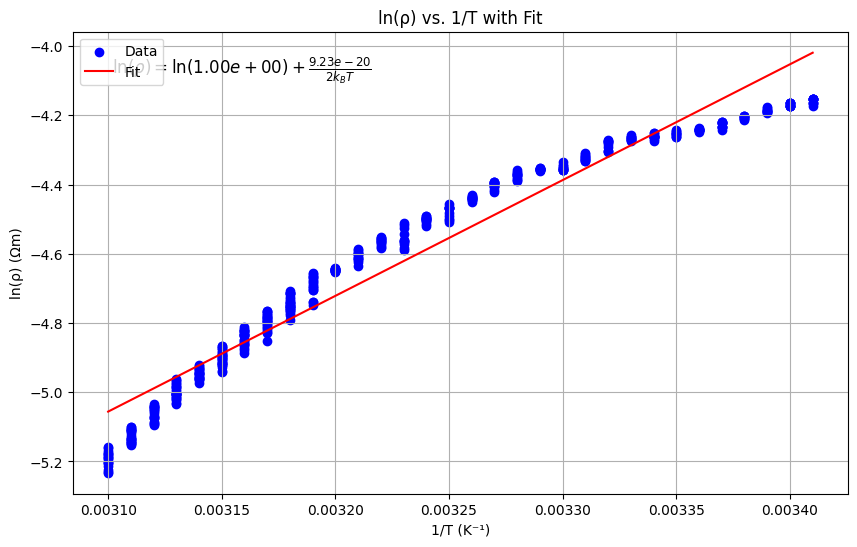

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd
from google.colab import files

# Define the fitting equation
def resistivity_model(T_inv, a, b):
    """
    Model for resistivity as a function of temperature.
    a: pre-exponential factor (log(a) is used)
    b: fitting parameter (related to activation energy)
    T_inv: 1/T (inverse temperature in K⁻¹)
    """
    # Ensure the model avoids log(0) by checking for small values of a
    if a <= 0:
        return np.inf
    return np.log(a) + (b / (2 * 1.38e-23)) * T_inv

# Function to upload and read data
def read_data():
    try:
        # Prompt user to upload the file
        uploaded = files.upload()

        # Read the first uploaded file
        for filename in uploaded.keys():
            print(f"File uploaded: {filename}")
            # Read CSV file into a pandas DataFrame
            data = pd.read_csv(filename)

            # Print column names to check
            print(f"Columns in the file: {data.columns.tolist()}")
            return data
    except Exception as e:
        print(f"Error reading file: {e}")
        return None

# Main function to fit and plot resistivity data
def fit_resistivity():
    # Load data from the uploaded file
    data = read_data()
    if data is None:
        print("No data loaded. Exiting.")
        return

    # Check for necessary columns
    try:
        log_rho = data['ln(ρ) (Ωm)'].to_numpy()  # Updated column name for resistivity
        T_inv = data['1/T'].to_numpy()  # Updated column name for 1/T
    except KeyError as e:
        print(f"Column not found: {e}")
        return

    # Remove invalid values (NaN or Inf)
    mask = np.isfinite(log_rho) & np.isfinite(T_inv)
    log_rho_clean = log_rho[mask]
    T_inv_clean = T_inv[mask]

    if len(log_rho_clean) == 0 or len(T_inv_clean) == 0:
        print("All data points contain NaN or Inf. Cannot proceed with curve fitting.")
        return

    # Perform the curve fitting
    try:
        # Initial guesses for the parameters
        initial_guess = [1e-6, 1e-20]  # Adjust based on expected scale
        popt, pcov = curve_fit(resistivity_model, T_inv_clean, log_rho_clean, p0=initial_guess)

        # Extract fitted parameters and their uncertainties
        a_fit = np.exp(popt[0])  # p0 corresponds to log(a)
        b_fit = popt[1]
        a_error, b_error = np.sqrt(np.diag(pcov))

        # Display results
        print(f"Fitted Parameters:")
        print(f"  a (pre-exponential factor) = {a_fit:.4e} ± {a_error:.4e} Ωm")
        print(f"  b (fitting parameter) = {b_fit:.4e} ± {b_error:.4e} J")

        # Generate fit line
        T_inv_fit = np.linspace(min(T_inv_clean), max(T_inv_clean), 500)
        log_rho_fit = resistivity_model(T_inv_fit, *popt)

        # Plot data and fit
        plt.figure(figsize=(10, 6))
        plt.scatter(T_inv_clean, log_rho_clean, color='blue', label='Data')
        plt.plot(T_inv_fit, log_rho_fit, color='red', label='Fit')

        # Display the equation on the plot
        equation = f"$\\ln(\\rho) = \\ln({a_fit:.2e}) + \\frac{{{b_fit:.2e}}}{{2k_B T}}$"
        plt.text(0.05, 0.95, equation, transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')

        # Labels and title
        plt.xlabel('1/T (K⁻¹)')
        plt.ylabel('ln(ρ) (Ωm)')
        plt.title('ln(ρ) vs. 1/T with Fit')
        plt.legend()
        plt.grid(True)
        plt.show()

    except Exception as e:
        print(f"An error occurred during curve fitting: {e}")

# Run the fitting function
fit_resistivity()